In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
import mlflow
import mlflow.sklearn

In [2]:
data_file = "../data/train.csv"

In [3]:
data = pd.read_csv(data_file)


In [4]:
data.head()

,booking_id,booking_date,arrival_date,lead_time,stays_weekend,stays_weekday,adults,children,babies,meal_plan,...,deposit_type,agent_id,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,special_requests,avg_daily_rate,parking_spaces,cancellation_fee_charged,is_canceled
0,8610,2023-05-14,2023-06-24,41,4,1,2,2.0,0,Bed & Breakfast,...,No Deposit,28,1,1.0,4,1,60.37,0,0,0
1,8405,2023-02-21,2023-04-13,51,0,2,4,0.0,0,Bed & Breakfast,...,No Deposit,12,0,3.0,3,3,81.49,0,0,0
2,8953,2023-11-18,2023-12-25,37,4,1,4,0.0,0,Bed & Breakfast,...,No Deposit,15,0,1.0,0,1,127.29,0,1,1
3,9807,2023-03-10,2023-04-22,43,0,2,2,0.0,0,Bed & Breakfast,...,Refundable,28,0,1.0,0,3,61.48,1,1,0
4,11161,2023-11-23,2023-11-26,3,1,7,2,0.0,0,Self Catering,...,No Deposit,6,1,0.0,3,1,74.73,1,0,0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9696 entries, 0 to 9695
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   booking_id                      9696 non-null   int64  
 1   booking_date                    9696 non-null   str    
 2   arrival_date                    9696 non-null   str    
 3   lead_time                       9696 non-null   int64  
 4   stays_weekend                   9696 non-null   int64  
 5   stays_weekday                   9696 non-null   int64  
 6   adults                          9696 non-null   int64  
 7   children                        9199 non-null   float64
 8   babies                          9696 non-null   int64  
 9   meal_plan                       9696 non-null   str    
 10  country                         9696 non-null   str    
 11  market_segment                  9696 non-null   str    
 12  room_type                       9696 non-null

In [6]:
data.isnull().sum()

booking_id                           0
booking_date                         0
arrival_date                         0
lead_time                            0
stays_weekend                        0
stays_weekday                        0
adults                               0
children                           497
babies                               0
meal_plan                            0
country                              0
market_segment                       0
room_type                            0
deposit_type                         0
agent_id                             0
is_repeated_guest                    0
previous_cancellations            1665
previous_bookings_not_canceled       0
special_requests                     0
avg_daily_rate                       0
parking_spaces                       0
cancellation_fee_charged             0
is_canceled                          0
dtype: int64

In [7]:
data.isnull().sum()

booking_id                           0
booking_date                         0
arrival_date                         0
lead_time                            0
stays_weekend                        0
stays_weekday                        0
adults                               0
children                           497
babies                               0
meal_plan                            0
country                              0
market_segment                       0
room_type                            0
deposit_type                         0
agent_id                             0
is_repeated_guest                    0
previous_cancellations            1665
previous_bookings_not_canceled       0
special_requests                     0
avg_daily_rate                       0
parking_spaces                       0
cancellation_fee_charged             0
is_canceled                          0
dtype: int64

In [8]:
train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data['is_canceled'])

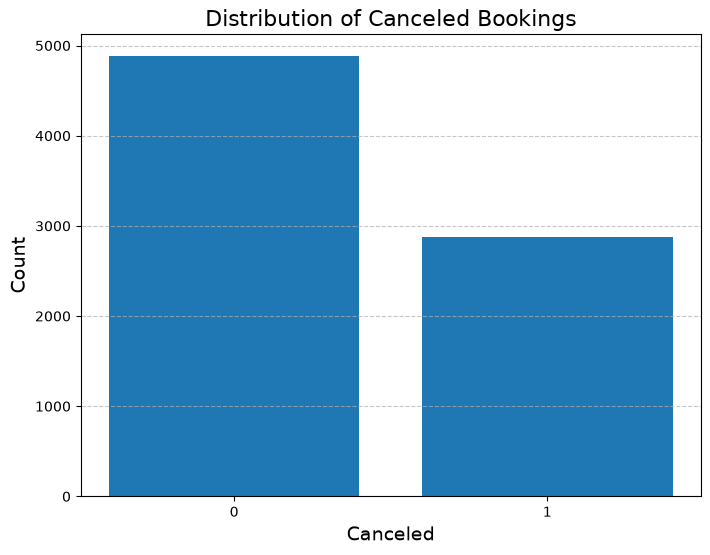

In [9]:
drafted_counts = train['is_canceled'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Canceled Bookings', fontsize=16)
plt.xlabel('Canceled', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [10]:
canceled_percentage = train['is_canceled'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {canceled_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {canceled_percentage.get(1, 0):.2f}%")

Percentage of 0: 62.92%
Percentage of 1: 37.08%


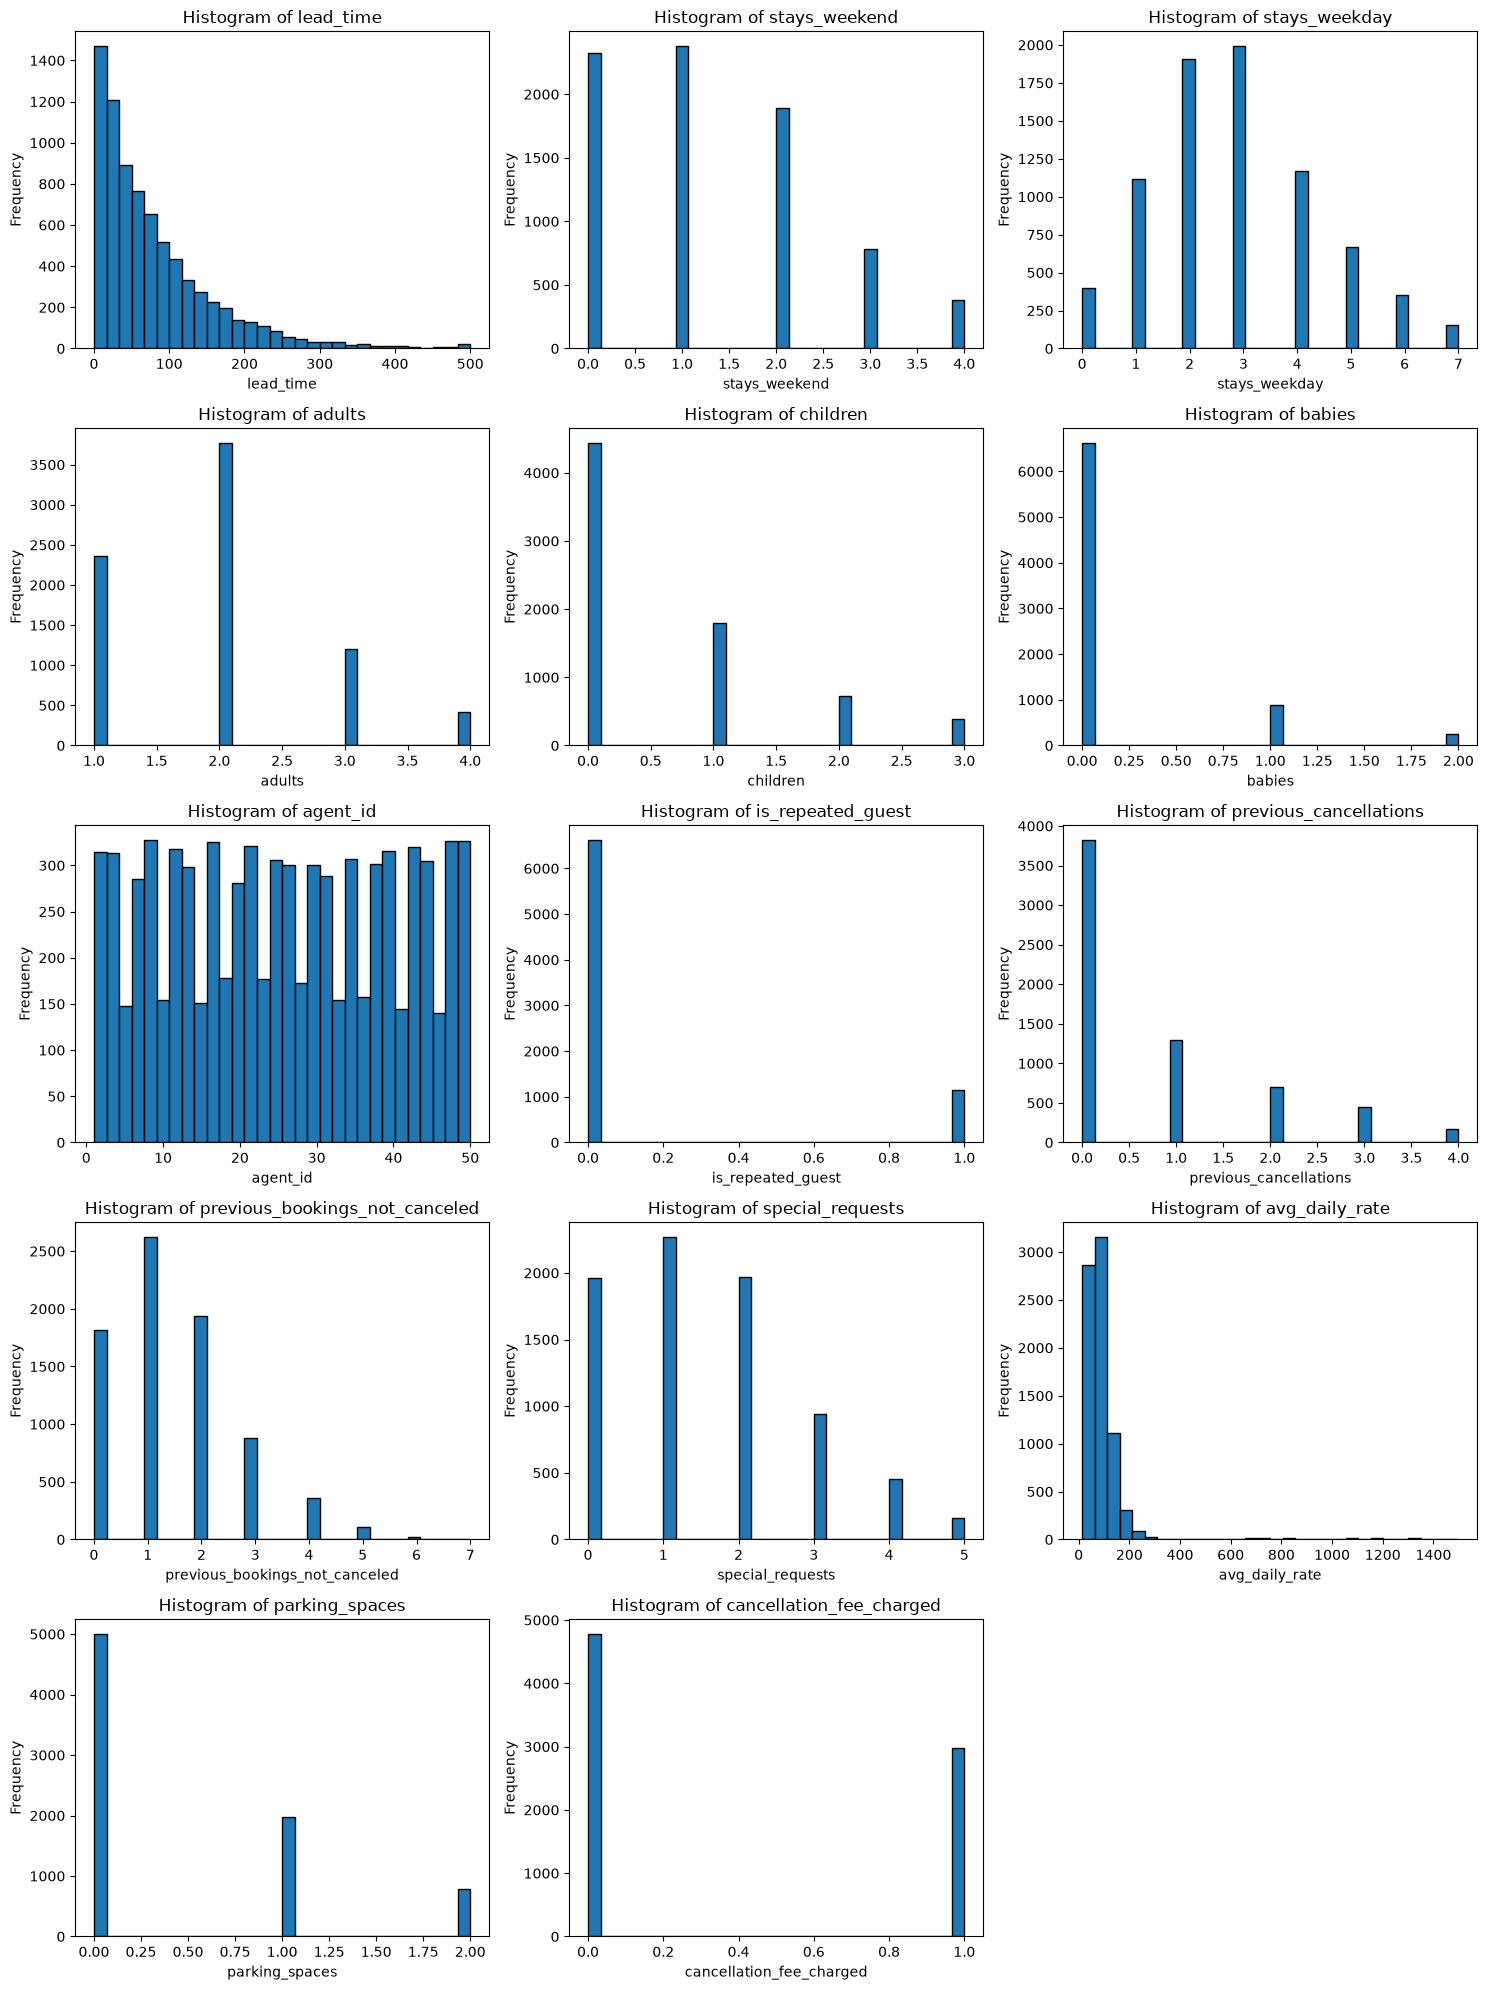

In [11]:
# Extraxt numeric columns (excluding the 'Id' and 'Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['booking_id', 'is_canceled'])  # Exclude 'booking_id' and 'is_canceled'

# Plot
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

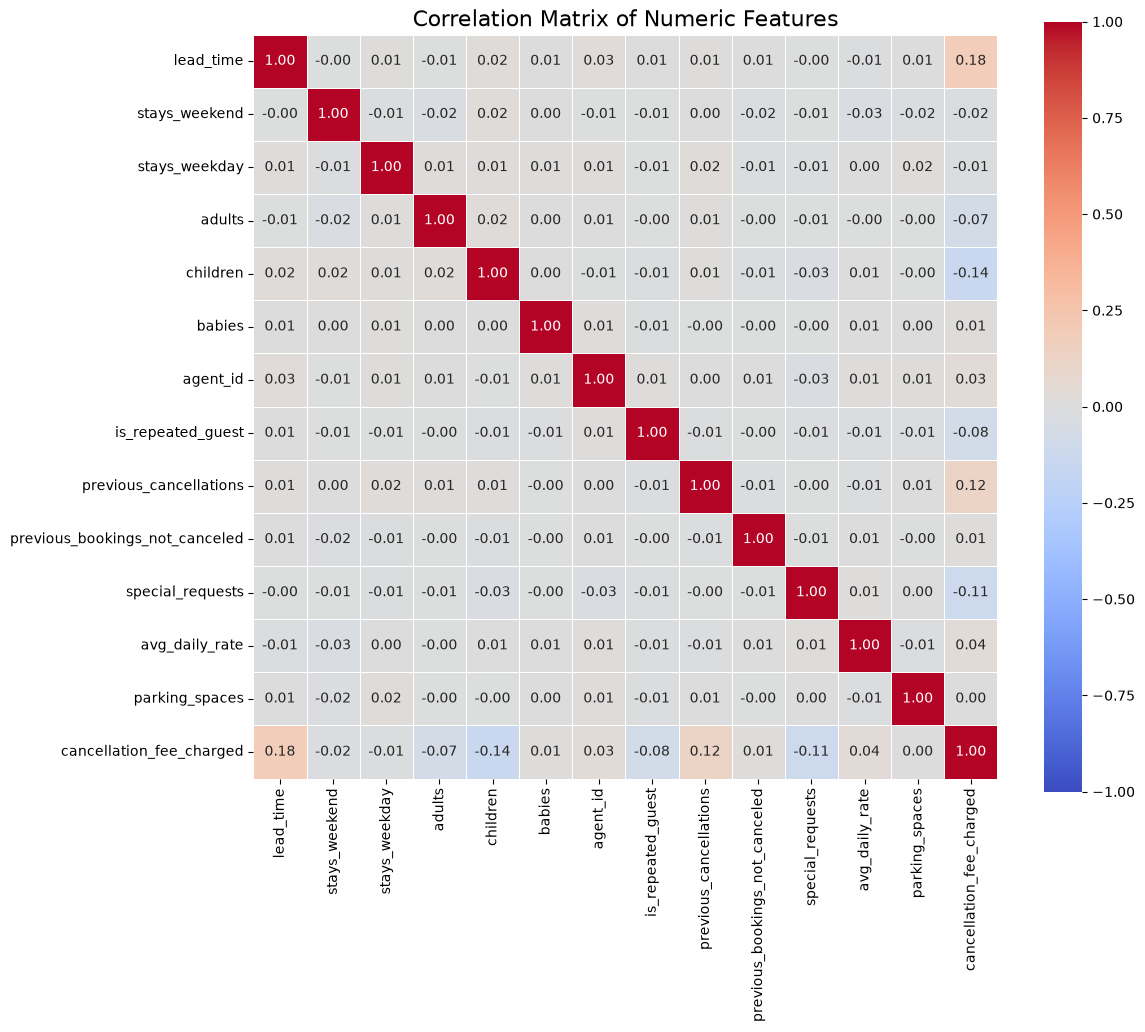

In [12]:
# Extract numeric columns (excluding the 'booking_id' and 'is_canceled' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['booking_id', 'is_canceled'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

In [13]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


booking_date: 730 levels
arrival_date: 950 levels
meal_plan: 4 levels
country: 54 levels
market_segment: 5 levels
room_type: 3 levels
deposit_type: 3 levels


C:\Users\user\AppData\Local\Temp\ipykernel_27700\3540777253.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object', 'category']).columns


C:\Users\user\AppData\Local\Temp\ipykernel_27700\1175003637.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object', 'category']).columns


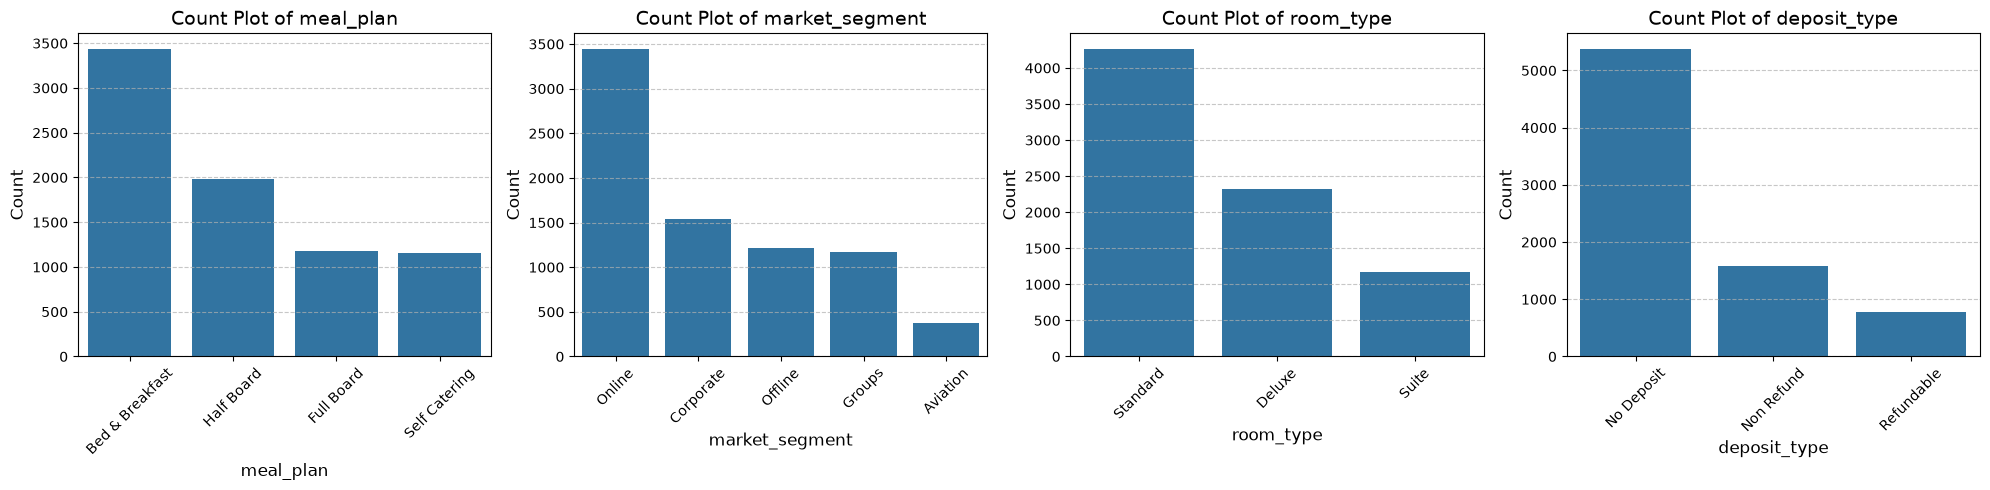

In [14]:
# Extract categorical features (object or category) and exclude the 'School' columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop(['booking_date','arrival_date','country']) 

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Count plots for each categorical features
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_27700\2417514356.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object', 'category']).columns


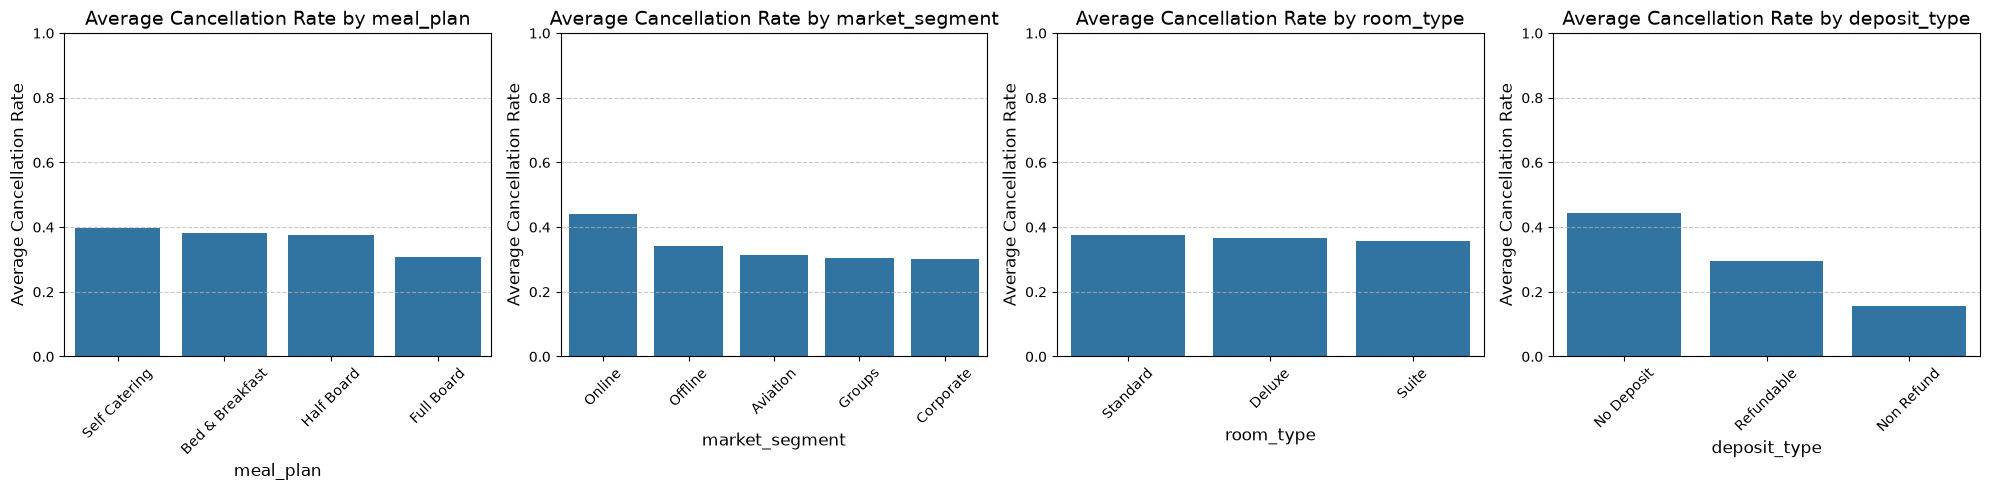

In [15]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop(['booking_date','arrival_date','country'])

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot the mean value of 'Drafted' for each categorical feature as bar charts
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Cancellation Rate by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Cancellation Rate', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [16]:
# Drop unused columns
train = train.drop(columns=["booking_id", "arrival_date","booking_date","cancellation_fee_charged"])
test = test.drop(columns=["booking_id","arrival_date","booking_date","cancellation_fee_charged"])

In [17]:
# Columns to impute with the mean
cols_to_fill = ['children', 'previous_cancellations']
# Impute both train and test using the means computed from the training data
for col in cols_to_fill:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

In [18]:
train.isnull().sum()

lead_time                         0
stays_weekend                     0
stays_weekday                     0
adults                            0
children                          0
babies                            0
meal_plan                         0
country                           0
market_segment                    0
room_type                         0
deposit_type                      0
agent_id                          0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
special_requests                  0
avg_daily_rate                    0
parking_spaces                    0
is_canceled                       0
dtype: int64

In [19]:
test.isnull().sum()

lead_time                         0
stays_weekend                     0
stays_weekday                     0
adults                            0
children                          0
babies                            0
meal_plan                         0
country                           0
market_segment                    0
room_type                         0
deposit_type                      0
agent_id                          0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
special_requests                  0
avg_daily_rate                    0
parking_spaces                    0
is_canceled                       0
dtype: int64

In [20]:
# Label-encode the categorical features
label_encoders = {}
for c in ["meal_plan", "market_segment","room_type","deposit_type","country"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

In [28]:
from xgboost import XGBClassifier
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("http://ec2-32-195-106-158.compute-1.amazonaws.com:8050")

mlflow.set_experiment("hotel_booking_cancellation")

# Split into features and target
X = train.drop(columns=["is_canceled"])
y = train["is_canceled"]

# Hyperparameters
n_estimators = 250
max_depth = 4
learning_rate = 0.15
subsample = 0.8
colsample_bytree = 0.8
random_state = 2025
n_splits = 5

with mlflow.start_run(run_name="XGBoost_1"):

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=random_state,
        eval_metric="logloss"
    )

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    auc_scores = []
    accuracy_scores = []
    confusion_matrices = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        print(f"Fold {fold + 1}")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        # Train
        model.fit(X_train, y_train)

        # Predict probabilities and classes
        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]

        y_valid_pred = (
            y_valid_pred_proba >= 0.5
        ).astype(int)

        # Metrics
        auc = roc_auc_score(
            y_valid,
            y_valid_pred_proba
        )

        accuracy = accuracy_score(
            y_valid,
            y_valid_pred
        )

        matrix = confusion_matrix(
            y_valid,
            y_valid_pred
        )

        auc_scores.append(auc)
        accuracy_scores.append(accuracy)
        confusion_matrices.append(matrix)

        print(f"  AUC: {auc:.4f}")
        print(f"  Accuracy: {accuracy:.4f}")
        print("  Confusion matrix:")
        print(matrix)

    # General metrics
    mean_auc = np.mean(auc_scores)
    mean_accuracy = np.mean(accuracy_scores)

    std_auc = np.std(auc_scores)
    std_accuracy = np.std(accuracy_scores)

    total_confusion_matrix = np.sum(
        confusion_matrices,
        axis=0
    )

    # Log parameters
    mlflow.log_param("model_type","XGBClassifier")
    mlflow.log_param("n_estimators",n_estimators)
    mlflow.log_param("max_depth",max_depth)
    mlflow.log_param("learning_rate",learning_rate)
    mlflow.log_param("subsample",subsample)
    mlflow.log_param("colsample_bytree",colsample_bytree)
    mlflow.log_param("random_state",random_state)
    mlflow.log_param("cv_folds",n_splits)
    mlflow.log_param("prediction_threshold", 0.5)

    # Log metrics
    mlflow.log_metric("mean_auc",mean_auc)
    mlflow.log_metric("mean_accuracy",mean_accuracy)
    mlflow.log_metric("std_auc",std_auc)
    mlflow.log_metric("std_accuracy",std_accuracy)
    print("\nAverage Validation AUC:",round(mean_auc, 4))
    print("Average Validation Accuracy:",round(mean_accuracy, 4))
    print("\nAccumulated Confusion Matrix:")
    print(total_confusion_matrix)

    # Confusion matrix artifact
    disp = ConfusionMatrixDisplay(
        confusion_matrix=total_confusion_matrix
    )

    disp.plot()

    plt.title("XGBoost - Accumulated Confusion Matrix - 5 Fold CV")
    plt.savefig("confusion_matrix_xgboost.png",bbox_inches="tight")
    plt.close()

    mlflow.log_artifact("confusion_matrix_xgboost.png")

    # Train final model with all data
    final_model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=random_state,
        eval_metric="logloss"
    )

    final_model.fit(X, y)

    # Log final model
    mlflow.xgboost.log_model(
        final_model,
        artifact_path="model"
    )

Fold 1
  AUC: 0.7614
  Accuracy: 0.7139
  Confusion matrix:
[[798 178]
 [266 310]]
Fold 2
  AUC: 0.7879
  Accuracy: 0.7485
  Confusion matrix:
[[823 153]
 [237 338]]
Fold 3
  AUC: 0.7764
  Accuracy: 0.7234
  Confusion matrix:
[[807 169]
 [260 315]]
Fold 4
  AUC: 0.7805
  Accuracy: 0.7286
  Confusion matrix:
[[812 164]
 [257 318]]
Fold 5
  AUC: 0.7892
  Accuracy: 0.7369
  Confusion matrix:
[[823 153]
 [255 320]]

Average Validation AUC: 0.7791
Average Validation Accuracy: 0.7303

Accumulated Confusion Matrix:
[[4063  817]
 [1275 1601]]


2026/09/05 00:48:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost_1 at: http://ec2-32-195-106-158.compute-1.amazonaws.com:8050/#/experiments/1/runs/6e6e7317921c46b585e5e30c20be7351
🧪 View experiment at: http://ec2-32-195-106-158.compute-1.amazonaws.com:8050/#/experiments/1


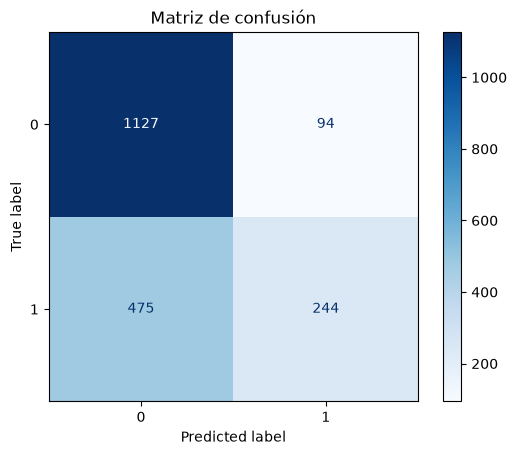

AUC on test set: 0.7717
Accuracy on test set: 0.7067
F1-score on test set: 0.4617


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

x_test = test.drop(columns=["is_canceled"])  
# Assuming 'is_canceled' is the target column in the test set
y_test_pred_proba = model.predict_proba(x_test)[:, 1]
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

y_test = test["is_canceled"]  # Assuming you want to compare against the training labels
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

# Graficar
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Matriz de confusión")
plt.show()

# Imprimir métricas de evaluación
test_auc = roc_auc_score(y_test, y_test_pred_proba) 
print(f"AUC on test set: {test_auc:.4f}")
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy on test set: {test_accuracy:.4f}")
test_f1 = f1_score(y_test, y_test_pred)
print(f"F1-score on test set: {test_f1:.4f}")

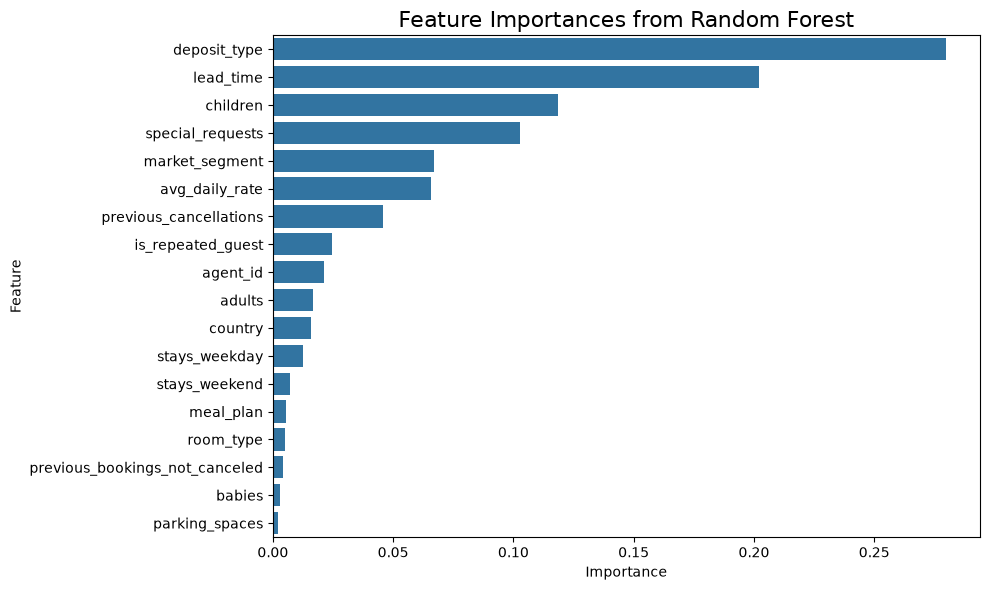

In [ ]:
# Create a DataFrame of features and their importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()